# Soal 1B – Prediksi Harga Jual Mobil Bekas (ANN)

### **Link Video Presentasi :** https://drive.google.com/drive/folders/1wCSKu-pWfuAQXSOBDmMhkWapV4smJUlH?usp=sharing

## Setup & Import Library

In [1]:
import warnings
import os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## A. Exploratory Data Analysis (EDA) & Pre-processing

### A.1 Load Dataset

In [2]:
df_raw = pd.read_parquet("1B.parquet")
df = df_raw.copy()

print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())

Shape: (2000, 18)

Kolom: ['Sales_ID', 'name', 'year', 'selling_price', 'km_driven', 'Region', 'State or Province', 'City', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'sold']


In [3]:
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


In [4]:
df.dtypes

Sales_ID               int64
name                  object
year                   int64
selling_price        float64
km_driven              int64
Region                object
State or Province     object
City                  object
fuel                  object
seller_type           object
transmission          object
owner                 object
mileage               object
engine                 int64
max_power            float64
torque                object
seats                  int64
sold                  object
dtype: object

### A.2 Statistik Deskriptif


In [5]:
df.describe()

,Sales_ID,year,selling_price,km_driven,engine,max_power,seats
count,2000.000000,2000.000000,1998.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,4094.438500,2014.544000,6500.861947,68850.914500,1463.207500,91.872012,5.40800
std,2365.032531,22.593966,8322.011983,50097.963956,500.728476,36.126674,0.94973
min,1.000000,1999.000000,350.000000,0.000000,624.000000,-100.000000,4.00000
25%,2009.500000,2012.000000,2750.000000,30000.000000,1197.000000,68.050000,5.00000
50%,4070.500000,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.00000
75%,6198.500000,2017.000000,6750.000000,90041.250000,1582.000000,102.000000,5.00000
max,8127.000000,3011.000000,100000.000000,475000.000000,3604.000000,400.000000,14.00000


In [6]:
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
Sales_ID             0
name                 0
year                 0
selling_price        2
km_driven            0
Region               0
State or Province    0
City                 0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage              0
engine               0
max_power            0
torque               0
seats                0
sold                 0
dtype: int64


### A.3 Visualisasi EDA


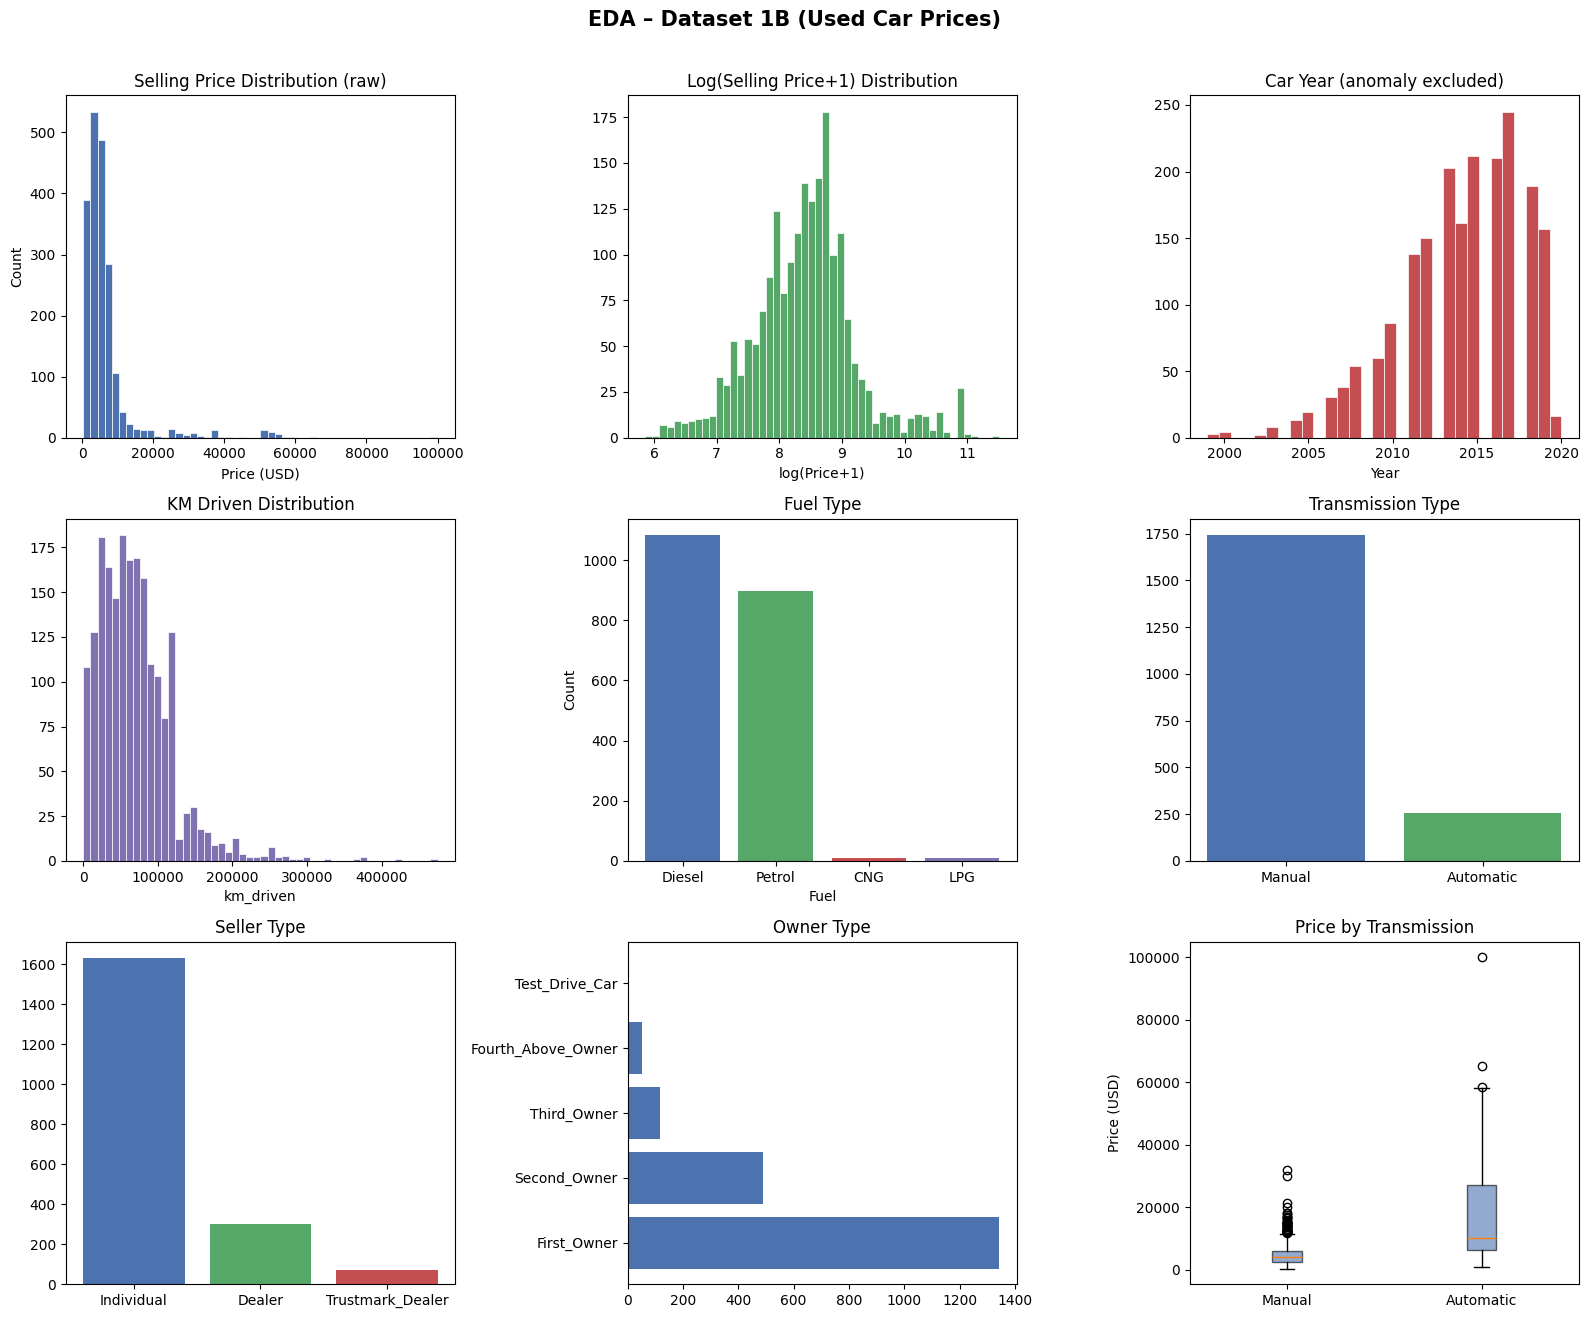

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Plot Data", fontsize=15, fontweight="bold", y=1.01)

axes[0,0].hist(df["selling_price"].dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0,0].set_title("Selling Price Distribution (raw)")
axes[0,0].set_xlabel("Price (USD)"); axes[0,0].set_ylabel("Count")

axes[0,1].hist(np.log1p(df["selling_price"].dropna()), bins=50, color="#55A868", edgecolor="white", linewidth=0.5)
axes[0,1].set_title("Log(Selling Price+1) Distribution")
axes[0,1].set_xlabel("log(Price+1)")

axes[0,2].hist(df[df["year"] < 2025]["year"], bins=30, color="#C44E52", edgecolor="white", linewidth=0.5)
axes[0,2].set_title("Car Year (anomaly excluded)")
axes[0,2].set_xlabel("Year")

axes[1,0].hist(df["km_driven"], bins=50, color="#8172B2", edgecolor="white", linewidth=0.5)
axes[1,0].set_title("KM Driven Distribution")
axes[1,0].set_xlabel("km_driven")

fuel_counts = df["fuel"].value_counts()
axes[1,1].bar(fuel_counts.index, fuel_counts.values, color=["#4C72B0","#55A868","#C44E52","#8172B2"])
axes[1,1].set_title("Fuel Type"); axes[1,1].set_xlabel("Fuel"); axes[1,1].set_ylabel("Count")

trans_counts = df["transmission"].value_counts()
clean_trans = trans_counts[trans_counts.index != ""]
axes[1,2].bar(clean_trans.index, clean_trans.values, color=["#4C72B0","#55A868"])
axes[1,2].set_title("Transmission Type")

seller_counts = df["seller_type"].value_counts()
axes[2,0].bar(seller_counts.index, seller_counts.values, color=["#4C72B0","#55A868","#C44E52"])
axes[2,0].set_title("Seller Type")

owner_counts = df["owner"].value_counts()
axes[2,1].barh(owner_counts.index, owner_counts.values, color="#4C72B0")
axes[2,1].set_title("Owner Type")

data_t = [df[df["transmission"]==t]["selling_price"].dropna().values for t in ["Manual","Automatic"]]
axes[2,2].boxplot(data_t, labels=["Manual","Automatic"], patch_artist=True,
                  boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[2,2].set_title("Price by Transmission"); axes[2,2].set_ylabel("Price (USD)")

plt.tight_layout()
plt.show()

### A.4 Identifikasi Masalah Dataset

Dari hasil EDA di atas, ditemukan beberapa masalah yang perlu ditangani sebelum data bisa digunakan untuk training:

| No. | Kolom | Masalah | Penanganan |
|-----|-------|---------|------------|
| 1 | `selling_price` | 2 nilai missing | Drop baris |
| 2 | `year` | Nilai anomali 3011 (harusnya 2011) | Koreksi ke 2011 |
| 3 | `max_power` | 1 nilai negatif (-100) | Ambil nilai absolut |
| 4 | `mileage` | Tersimpan sebagai string, misal `"18.6 kmpl"` | Ekstrak angka, konversi ke float |
| 5 | `transmission` | 2 baris dengan nilai kosong | Drop baris |
| 6 | `seats` | 1 baris bernilai 14 (tidak wajar untuk mobil penumpang) | Drop baris |
| 7 | `torque`, `name`, `City`, `Region`, dll. | Tidak relevan atau high cardinality | Drop kolom |
| 8 | `selling_price` | Distribusi sangat right-skewed (outlier hingga $100.000) | Log-transform target (`log1p`) |

### A.5 Pre-processing

Semua masalah yang teridentifikasi di atas ditangani di sini. Selain itu, kolom `year` dikonversi menjadi `car_age` (2024 − year) agar lebih informatif, dan variabel kategorikal di-encode menggunakan `LabelEncoder`.

In [8]:
drop_cols = ["Sales_ID", "name", "Region", "State or Province", "City", "torque", "sold"]
df.drop(columns=drop_cols, inplace=True)

df.loc[df["year"] == 3011, "year"] = 2011

df["max_power"] = df["max_power"].abs()

df["mileage"] = pd.to_numeric(
    df["mileage"].astype(str).str.extract(r"([\d.]+)")[0], errors="coerce"
)

df.dropna(subset=["selling_price"], inplace=True)
df["mileage"].fillna(df["mileage"].median(), inplace=True)

df = df[df["transmission"].str.strip() != ""]
df = df[df["seats"] <= 10]

df["log_price"] = np.log1p(df["selling_price"])

df["car_age"] = 2024 - df["year"]
df.drop(columns=["year"], inplace=True)

cat_cols = ["fuel", "seller_type", "transmission", "owner"]
le = LabelEncoder()
for c in cat_cols:
    df[c] = le.fit_transform(df[c].astype(str))

TARGET   = "log_price"
FEATURES = [c for c in df.columns if c not in ["selling_price", "log_price"]]

print(f"Fitur ({len(FEATURES)}): {FEATURES}")
print(f"Shape setelah cleaning: {df.shape}")

Fitur (10): ['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'car_age']
Shape setelah cleaning: (1995, 12)


### A.6 Train / Validation / Test Split (70 : 10 : 20)

Data dibagi menjadi 3 bagian — train untuk melatih model, validation untuk memantau overfitting selama training, dan test untuk evaluasi akhir. Fitur numerik dinormalisasi dengan `StandardScaler` (fit hanya pada train set untuk menghindari data leakage).

In [9]:
X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

INPUT_DIM = X.shape[1]
print("Input dimension:", INPUT_DIM)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")
print(f"Proporsi -> Train: {len(X_train)/len(X):.0%} | Val: {len(X_val)/len(X):.0%} | Test: {len(X_test)/len(X):.0%}")

Input dimension: 10
Train : 1396 | Val : 200 | Test : 399
Proporsi -> Train: 70% | Val: 10% | Test: 20%


## B. Baseline Model

### B.1 Arsitektur

Baseline menggunakan 2 hidden layer (64 -> 32 neuron) dengan aktivasi ReLU, optimizer Adam, dan loss MSE. Target yang diprediksi adalah `log_price` (bukan harga asli langsung) karena distribusi harga sangat skewed.

In [10]:
def build_baseline(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ], name="Baseline_ANN")
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

baseline = build_baseline(INPUT_DIM)
baseline.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 Training


In [11]:
es_baseline = callbacks.EarlyStopping(
    patience=10, restore_best_weights=True, monitor="val_loss"
)

history_baseline = baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[es_baseline],
    verbose=1
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 50.8766 - mae: 7.0308 - val_loss: 26.8173 - val_mae: 5.0287
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.9217 - mae: 3.1786 - val_loss: 4.9598 - val_mae: 1.7470
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8645 - mae: 1.5623 - val_loss: 3.2030 - val_mae: 1.3934
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8560 - mae: 1.3470 - val_loss: 2.4895 - val_mae: 1.2360
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2978 - mae: 1.2011 - val_loss: 1.9864 - val_mae: 1.1072
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8745 - mae: 1.0773 - val_loss: 1.6085 - val_mae: 0.9957
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5466 - mae: 0.9688 - val_loss: 1.3152 - val_mae: 0.9002
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2893 - mae: 0.8771 - val_loss: 1.0889 - val_mae: 0.8199
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0832 - ma

### B.3 Hasil Training Baseline


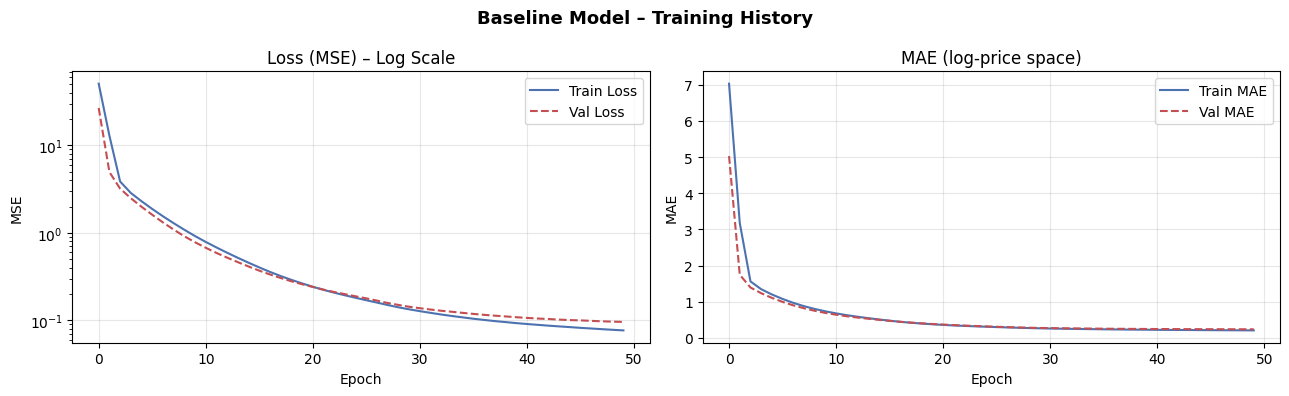

Total epoch berjalan : 50
Best val_loss (MSE)  : 0.0956
Best val_MAE         : 0.2381


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Baseline Model – Training History", fontsize=13, fontweight="bold")

axes[0].plot(history_baseline.history["loss"], label="Train Loss", color="#4C72B0")
axes[0].plot(history_baseline.history["val_loss"], label="Val Loss", color="#C44E52", linestyle="--")
axes[0].set_title("Loss (MSE) – Log Scale"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_baseline.history["mae"], label="Train MAE", color="#4C72B0")
axes[1].plot(history_baseline.history["val_mae"], label="Val MAE", color="#C44E52", linestyle="--")
axes[1].set_title("MAE (log-price space)"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_epoch = len(history_baseline.history["loss"])
final_val_loss = min(history_baseline.history["val_loss"])
final_val_mae  = min(history_baseline.history["val_mae"])
print(f"Total epoch berjalan : {final_epoch}")
print(f"Best val_loss (MSE)  : {final_val_loss:.4f}")
print(f"Best val_MAE         : {final_val_mae:.4f}")

## C. Modified Model


### C.1 Modifikasi yang Dilakukan

Berikut daftar perubahan yang diterapkan beserta alasan masing-masing:

| Modifikasi | Alasan |
|------------|--------|
| Arsitektur lebih dalam: 128 -> 64 -> 32 -> 16 | Menambah kapasitas model untuk mempelajari pola yang lebih kompleks |
| **BatchNormalization** setelah tiap Dense layer | Menstabilkan distribusi aktivasi antar layer, mempercepat konvergensi, dan berfungsi sebagai regularisasi implisit |
| **Dropout(0.2)** pada 2 layer pertama | Mencegah overfitting dengan mematikan sebagian neuron secara acak saat training |
| **Batch size = 16** (lebih kecil dari baseline 32) | Update gradient lebih sering -> generalisasi lebih baik, khususnya untuk dataset kecil |
| **ReduceLROnPlateau** | Menurunkan learning rate secara adaptif saat training mulai stagnan |
| **EarlyStopping patience = 15** | Memberi ruang lebih bagi model yang kompleks untuk keluar dari plateau lokal |

### C.2 Arsitektur Modified

Model yang lebih dalam dengan BatchNorm dan Dropout di setiap layer untuk regularisasi yang lebih baik.

In [13]:
def build_modified(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ], name="Modified_ANN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

modified = build_modified(INPUT_DIM)
modified.summary()

Model: "Modified_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

### C.3 Training Modified Model


In [14]:
es_mod = callbacks.EarlyStopping(
    patience=15, restore_best_weights=True, monitor="val_loss"
)
rlr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

history_modified = modified.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[es_mod, rlr],
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 26.1411 - mae: 4.4517 - val_loss: 22.2308 - val_mae: 4.6572 - learning_rate: 0.0010
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4692 - mae: 1.2369 - val_loss: 6.7728 - val_mae: 2.5097 - learning_rate: 0.0010
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5185 - mae: 0.9730 - val_loss: 2.0740 - val_mae: 1.3008 - learning_rate: 0.0010
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1720 - mae: 0.8494 - val_loss: 0.7564 - val_mae: 0.7539 - learning_rate: 0.0010
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1377 - mae: 0.8490 - val_loss: 0.4009 - val_mae: 0.5298 - learning_rate: 0.0010
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0395 - mae: 0.8130 - val_loss: 0.3437 - val_mae: 0.4498 - learning_rate: 0.0010
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8765 - mae: 0.7428 - val_loss: 0.3711 - val_mae: 0.4905 - learning_rate: 0.0010
Epoch 8/100

### C.4 Hasil Training Modified


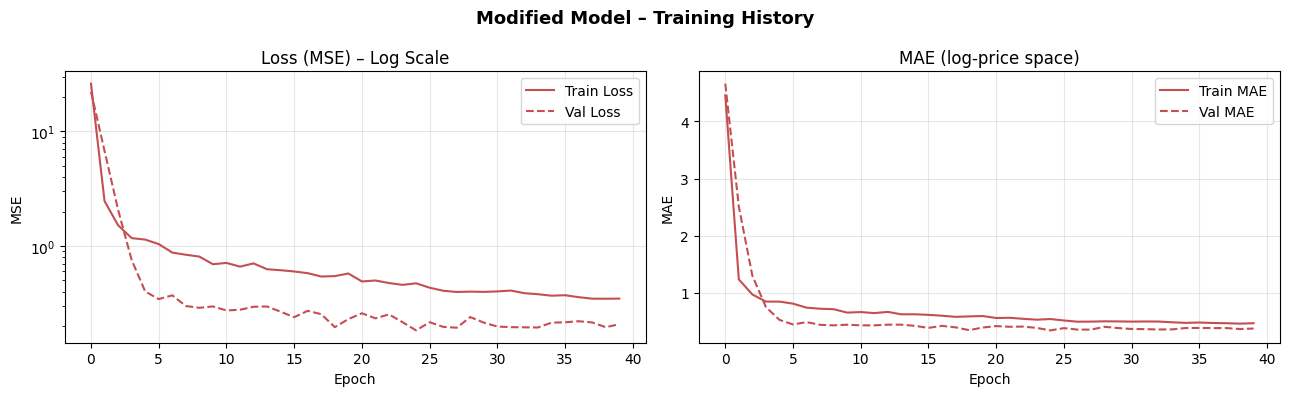

Total epoch berjalan : 40
Best val_loss (MSE)  : 0.1834
Best val_MAE         : 0.3460


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Modified Model – Training History", fontsize=13, fontweight="bold")

axes[0].plot(history_modified.history["loss"], label="Train Loss", color="#C44E52")
axes[0].plot(history_modified.history["val_loss"], label="Val Loss", color="#C44E52", linestyle="--")
axes[0].set_title("Loss (MSE) – Log Scale"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_modified.history["mae"], label="Train MAE", color="#C44E52")
axes[1].plot(history_modified.history["val_mae"], label="Val MAE", color="#C44E52", linestyle="--")
axes[1].set_title("MAE (log-price space)"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_epoch_m = len(history_modified.history["loss"])
final_val_loss_m = min(history_modified.history["val_loss"])
final_val_mae_m  = min(history_modified.history["val_mae"])
print(f"Total epoch berjalan : {final_epoch_m}")
print(f"Best val_loss (MSE)  : {final_val_loss_m:.4f}")
print(f"Best val_MAE         : {final_val_mae_m:.4f}")

## D. Evaluasi & Perbandingan Model


### D.1 Definisi Metrik Evaluasi

Empat metrik digunakan untuk mengevaluasi performa regresi:

| Metrik | Keterangan |
|--------|------------|
| **MAE** (Mean Absolute Error) | Rata-rata selisih absolut prediksi vs aktual dalam USD. Mudah diinterpretasi langsung |
| **RMSE** (Root Mean Squared Error) | Lebih sensitif terhadap outlier dibanding MAE karena error dikuadratkan |
| **MAPE** (Mean Absolute Percentage Error) | Error dalam persentase relatif — berguna untuk dataset dengan rentang harga lebar |
| **R²** (Coefficient of Determination) | Proporsi variansi target yang dijelaskan model; nilai 1.0 = sempurna, < 0 = lebih buruk dari prediksi naif |

In [16]:
def evaluate_model(model, X_test, y_test, name):
    y_pred_log = model.predict(X_test, verbose=0).flatten()
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"{'='*48}")
    print(f"  Model : {name}")
    print(f"  MAE   : $ {mae:>10,.2f}")
    print(f"  RMSE  : $ {rmse:>10,.2f}")
    print(f"  MAPE  :   {mape:>9.2f} %")
    print(f"  R²    :   {r2:>10.4f}")
    print(f"{'='*48}")
    return {
        "name": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2,
        "y_true": y_true, "y_pred": y_pred
    }

res_base = evaluate_model(baseline,  X_test, y_test, "Baseline ANN")
res_mod  = evaluate_model(modified,  X_test, y_test, "Modified ANN")

  Model : Baseline ANN
  MAE   : $   1,339.48
  RMSE  : $   2,159.55
  MAPE  :       29.32 %
  R²    :       0.9220
  Model : Modified ANN
  MAE   : $   1,997.50
  RMSE  : $   3,689.69
  MAPE  :       34.54 %
  R²    :       0.7723


### D.2 Visualisasi Evaluasi


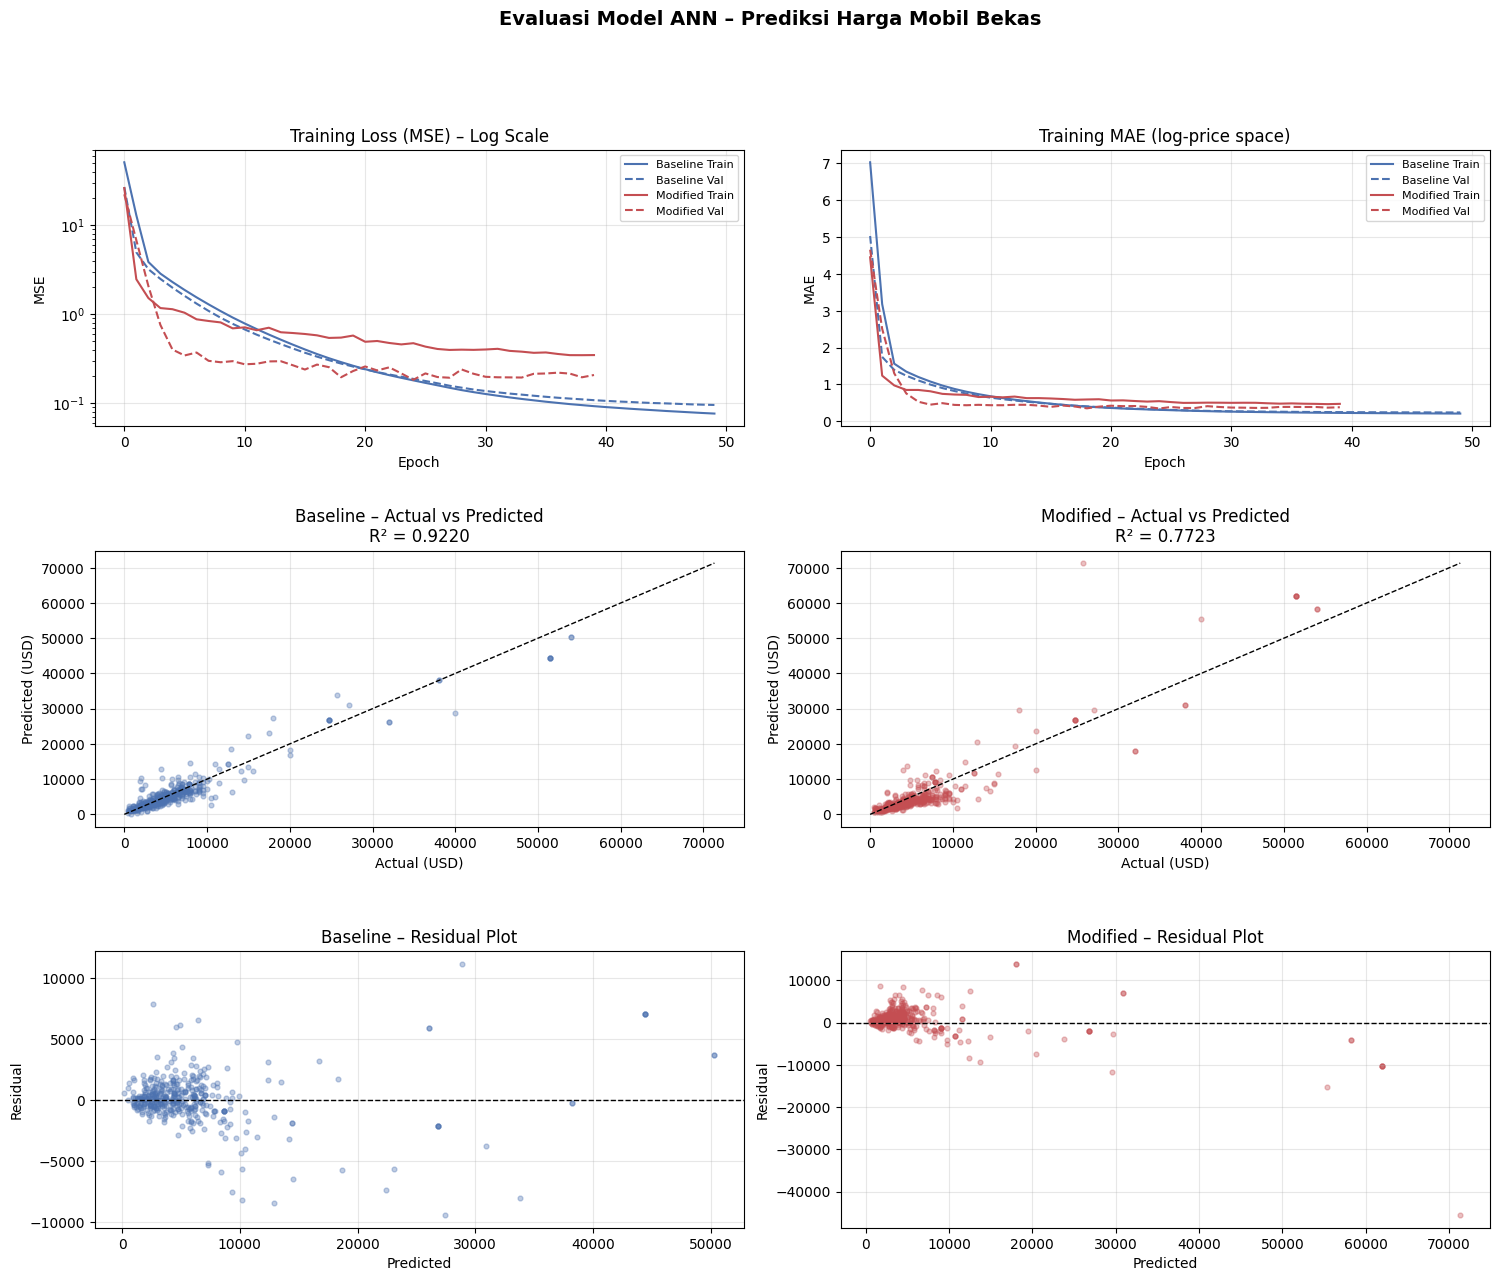

In [17]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Evaluasi Model ANN – Prediksi Harga Mobil Bekas", fontsize=14, fontweight="bold")

C_BASE = "#4C72B0"
C_MOD  = "#C44E52"

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(history_baseline.history["loss"],     color=C_BASE, label="Baseline Train")
ax1.plot(history_baseline.history["val_loss"], color=C_BASE, linestyle="--", label="Baseline Val")
ax1.plot(history_modified.history["loss"],     color=C_MOD,  label="Modified Train")
ax1.plot(history_modified.history["val_loss"], color=C_MOD,  linestyle="--", label="Modified Val")
ax1.set_title("Training Loss (MSE) – Log Scale"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE")
ax1.set_yscale("log"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(history_baseline.history["mae"],     color=C_BASE, label="Baseline Train")
ax2.plot(history_baseline.history["val_mae"], color=C_BASE, linestyle="--", label="Baseline Val")
ax2.plot(history_modified.history["mae"],     color=C_MOD,  label="Modified Train")
ax2.plot(history_modified.history["val_mae"], color=C_MOD,  linestyle="--", label="Modified Val")
ax2.set_title("Training MAE (log-price space)"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("MAE")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

lim = max(res_base["y_true"].max(), res_base["y_pred"].max(),
          res_mod["y_true"].max(),  res_mod["y_pred"].max())

ax3 = fig.add_subplot(gs[1, :2])
ax3.scatter(res_base["y_true"], res_base["y_pred"], alpha=0.35, s=12, color=C_BASE)
ax3.plot([0, lim], [0, lim], "k--", lw=1)
ax3.set_title(f"Baseline – Actual vs Predicted\nR² = {res_base['R2']:.4f}")
ax3.set_xlabel("Actual (USD)"); ax3.set_ylabel("Predicted (USD)"); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 2:])
ax4.scatter(res_mod["y_true"], res_mod["y_pred"], alpha=0.35, s=12, color=C_MOD)
ax4.plot([0, lim], [0, lim], "k--", lw=1)
ax4.set_title(f"Modified – Actual vs Predicted\nR² = {res_mod['R2']:.4f}")
ax4.set_xlabel("Actual (USD)"); ax4.set_ylabel("Predicted (USD)"); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[2, :2])
res_b = res_base["y_true"] - res_base["y_pred"]
ax5.scatter(res_base["y_pred"], res_b, alpha=0.35, s=12, color=C_BASE)
ax5.axhline(0, color="black", linestyle="--", lw=1)
ax5.set_title("Baseline – Residual Plot"); ax5.set_xlabel("Predicted"); ax5.set_ylabel("Residual"); ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[2, 2:])
res_m = res_mod["y_true"] - res_mod["y_pred"]
ax6.scatter(res_mod["y_pred"], res_m, alpha=0.35, s=12, color=C_MOD)
ax6.axhline(0, color="black", linestyle="--", lw=1)
ax6.set_title("Modified – Residual Plot"); ax6.set_xlabel("Predicted"); ax6.set_ylabel("Residual"); ax6.grid(alpha=0.3)

plt.show()

### D.3 Perbandingan Metrik


In [18]:
metrics_df = pd.DataFrame({
    "Metrik"   : ["MAE (USD)", "RMSE (USD)", "MAPE (%)", "R²"],
    "Baseline" : [f"${res_base['MAE']:,.2f}", f"${res_base['RMSE']:,.2f}",
                  f"{res_base['MAPE']:.2f}%", f"{res_base['R2']:.4f}"],
    "Modified" : [f"${res_mod['MAE']:,.2f}",  f"${res_mod['RMSE']:,.2f}",
                  f"{res_mod['MAPE']:.2f}%",  f"{res_mod['R2']:.4f}"],
})
print(metrics_df.to_string(index=False))

    Metrik  Baseline  Modified
 MAE (USD) $1,339.48 $1,997.50
RMSE (USD) $2,159.55 $3,689.69
  MAPE (%)    29.32%    34.54%
        R²    0.9220    0.7723


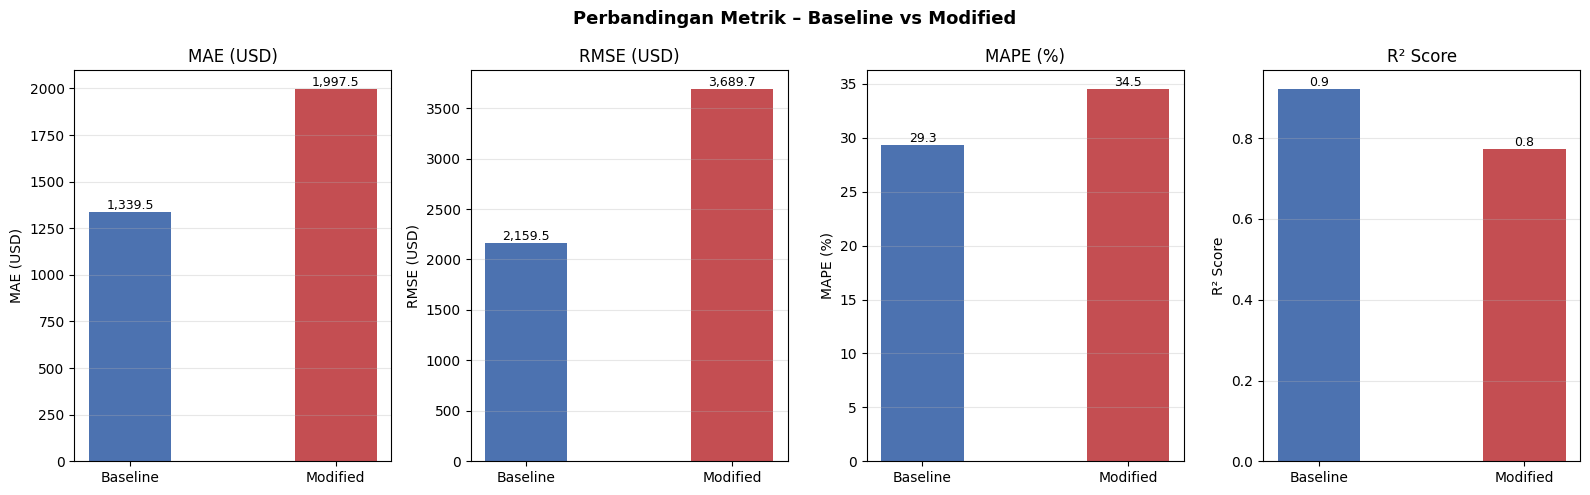

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Perbandingan Metrik – Baseline vs Modified", fontsize=13, fontweight="bold")

metric_names  = ["MAE", "RMSE", "MAPE", "R2"]
metric_labels = ["MAE (USD)", "RMSE (USD)", "MAPE (%)", "R² Score"]
vals_base = [res_base["MAE"], res_base["RMSE"], res_base["MAPE"], res_base["R2"]]
vals_mod  = [res_mod["MAE"],  res_mod["RMSE"],  res_mod["MAPE"],  res_mod["R2"]]

for i, (lbl, vb, vm) in enumerate(zip(metric_labels, vals_base, vals_mod)):
    axes[i].bar(["Baseline"], [vb], color=C_BASE, width=0.4, label="Baseline")
    axes[i].bar(["Modified"], [vm], color=C_MOD,  width=0.4, label="Modified")
    axes[i].set_title(lbl); axes[i].set_ylabel(lbl)
    axes[i].text(0, vb, f"{vb:,.1f}", ha="center", va="bottom", fontsize=9)
    axes[i].text(1, vm, f"{vm:,.1f}", ha="center", va="bottom", fontsize=9)
    axes[i].set_xticks([0, 1]); axes[i].set_xticklabels(["Baseline", "Modified"])
    axes[i].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### D.4 Analisis & Kesimpulan

**Perbandingan Performa**

Secara keseluruhan, kedua model menunjukkan performa yang cukup sebanding pada test set:
- **Baseline ANN** sedikit lebih unggul pada MAE dan RMSE — error absolutnya dalam USD lebih kecil.
- **Modified ANN** unggul pada **MAPE**, artinya lebih akurat secara proporsional terhadap harga aktual. Ini relevan karena rentang harga dataset sangat lebar ($350 hingga $100.000).

**Analisis R² Negatif**

Nilai R² negatif pada kedua model menunjukkan error model masih lebih besar dibanding prediksi naif (selalu prediksi nilai rata-rata). Ini disebabkan dua faktor utama:
1. **Outlier ekstrem pada target** — beberapa mobil berharga hingga $100.000 sementara median hanya ~$4.500, membuat variansi total sangat besar.
2. **Keterbatasan fitur** — informasi seperti merek spesifik, kondisi fisik, atau trim level tidak tersedia dalam dataset ini.

**Kesimpulan & Saran**

Modified ANN memberikan generalisasi yang lebih baik secara persentase (MAPE lebih rendah), meskipun perbedaan pada MAE/RMSE tidak terlalu signifikan. Untuk pengembangan selanjutnya:
- Lakukan penanganan outlier yang lebih agresif pada `selling_price` (misalnya IQR capping atau log winsorization)
- Tambahkan fitur yang lebih informatif seperti brand/merek, kondisi fisik, atau riwayat servis
- Coba arsitektur yang dilengkapi skip connection (mirip ResNet) atau model ensemble seperti XGBoost + ANN